## Intro to Quantum Programming - Spring 2025
## Homework 5: Due 04/22/25

For each exercise below, add as many cells as you want. To evaluate your submission, I will do **Restart and Run All**. . For help with Markdown, see [this link](https://www.markdownguide.org/).

In [1]:
# Here's a cell for import statements... add more if necessary (or just import below as needed)
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
# from the circuit library, import whatever you need to solve the problem
from qiskit.circuit.library import qaoa_ansatz

from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Statevector
import numpy as np

For all of the exercises below, you may use high-level circuits from [`qiskit.circuit.library`](https://docs.quantum.ibm.com/api/qiskit/circuit_library).  You cannot, however, use the `QuadraticProgram` class from the *Qiskit Optimization* package to create the `SparsePauliOp` for your Ising model.

Much of the text below, including the QUBO formulation, comes from F. Glover and G. Kochenberger, [A Tutorial on Forumalating and Using QUBO Models](https://arxiv.org/abs/1811.11538), 2018. I encourage you to take a look at that paper, which describes things like penalties for adding constraints.  In particular, the **number partitioning problem** is described in section 3.1, and the **minimum vertex cover problem** is described in section 4.1.

#### Summary
Here's a summary of what you will need to complete for this homework.
* 5.1: Create a function that converts a QUBO matrix into a `SparsePauliOp` that represents an Ising model.
* 5.2: Use QAOA to solve the number partitioning problem
* 5.2: Use QAOA to solve the minimum vertex cover problem.
* 5.4: (optional) For creativity points, take one of the problems from 5.2 or 5.3 and make some changes to try to get better results. Describe what you tried, and why you thought it might work, and whether it did give better results.

Each of the problems is described in detail below and is also in the tutorial paper linked in the prior cell. To get completeness and correctness points, we want to see a successful implementation of the QAOA algorithm. Only one repetition of the QAOA ansatz is required. Once you get the parameter from the optimizer, do one sampling run with 1000 (or more) shots and report:
* the bitstring and cost function value for the most frequently sampled outcome
* the bitstring and cost function value for the *best* sampled outcome, as well as the number of times that sample was measured

----
#### Exercise 5.1: Ising Model (20%)

The general form of a QUBO problem is:

$$
x^{T} Q x
$$

where \(x\) is a vector of binary variables and \(Q\) is the QUBO matrix that gives the coefficients of linear and quadratic terms. Since the diagonal elements are linear terms (only affected by one variable), another common expression is the following, where the diagonal elements are removed from the \(Q\) matrix and placed in a vector \(\mu\):

$$
x^{T} Q x + \mu x
$$

When converting the QUBO to an Ising model, the binary variables are replaced by spin variables, which take on +1 and -1 values, as follows:

$$
x_i = \frac{1 - z_i}{2}
$$

The Ising Hamiltonian is derived by replacing the spin variables \(\,(z_i)\) with the Pauli operator \(Z_i\), and the result is:

$$
H_C
= \sum_{i,j} \frac{Q_{ij}}{4} Z_i Z_j
  - \frac{1}{2} \sum_{i} \bigl(\mu_i + \sum_{j} Q_{ij}\bigr) Z_i
  + \sum_{i,j} \frac{Q_{ij}}{4}
  + \sum_{i} \frac{\mu_i}{2}
$$

The last two terms are constant scalar values (the *offset*) of the Ising model, but they do not affect the optimization.


Qiskit uses a [SparsePauliOp](https://docs.quantum.ibm.com/api/qiskit/1.3/qiskit.quantum_info.SparsePauliOp) to represent the measurement of this observable, and it is also used to generate the ansatz for the QAOA algorithm. The `SparsePauliOp` includes a list of Pauli strings and a corresponding vector of coefficients, one for each string.  In our case, the string will represent the $Z_i$ and $Z_i Z_j$ operators in the Hamiltonian above.

For an $n$-qubit state, the Pauli string consists of one character per qubit, where that character specifies the Pauli operator measured on that qubit: $I$ or $Z$ in our case.  The qubits are specified in little-endian order, with the least significant qubit (qubit 0) on the right.  For example, for a 5-qubit state, if we want to specify $Z_3$ (e.g, a $Z$ operator on qubit 3), the string is `IZIII`.  To specify the operator $Z_4 $Z_1$, the string is `ZIIZI`.

Create a function that takes in a 2D array (np.ndarray) as an argument, and returns a `SparsePauliOp`. Find each nonzero element of the matrix, construct the Pauli string, and compute the corresponding coefficient for that term in the Hamiltonian.  You will want to create a list of Pauli strings and a vector containing coefficients in the same order in order to construct the `SparsePauliOp` object.

Demonstrate your function using at least two different QUBO matrices (different than the ones used in the problems below).

----
#### Exercise 5.2: Number Partitioning problem  (40%)

A common version of this problem involves partitioning a set of numbers into two
subsets (denoted as subset 0 and subset 1) such that the subset sums are as close to each other as possible. We model this problem
as a QUBO instance as follows:

Consider a set of numbers $S = \{s_0, s_1, \ldots, s_{m-1}\}$. Let $x_j = 1$ if $S_j$ is a member of subset 1, and $x_j = 1$ otherwise.  (In other words, the value $x_j$ denotes the subset to which $S_j$ is assigned.) Then the sum of values in subset 1 is given by $$\mathit{sum}_1 = \sum_{j=0}^{m-1}{s_j x_j}$$ and the sum of values in subset 0 is $$\mathit{sum}_0 = \sum_{j=0}^{m-1}{s_j} - \sum_{j=0}^{m-1}{s_j x_j}.$$ The difference in the sums is $$\mathit{diff} = \sum_{j=0}^{m-1}{s_j} - 2\sum_{j=0}^{m-1}{s_j x_j} = c - 2\sum_{j=0}^{m-1}{s_j x_j}.$$

We approach the goal of minimizing this difference by minimizing the square of the difference:
$$\mathit{diff}\ ^2 = \left\{c - 2\sum_{j=0}^{m-1}{s_j x_j} \right\}^2 = c^2 + 4x^{T}Qx $$
where
$$ q_{ii} = s_i(s_i - c) \qquad \mathrm{and} \qquad q_{ij} = q_{ji} = s_i s_j.$$

Dropping the additive and multiplicative constants, our QUBO optimization problem becomes:
$$ \mathit{QUBO:} \; \min{y = x^{T}Qx} $$
with the elements $q_{ij}$ of matrix $Q$ as described above.


#### Solve using QAOA

Solve the problem given as an example in the paper:
$$S = \{25, 7,13, 31, 42,17, 21,10\}$$

A correct solution is $x = \{ 0,0,0,1,1,0,0,1 \}$, which results perfectly-matched sums of 83.  (NOTE: The result from Qiskit will be a bitstring, which shows bit values in the opposite order as this set/vector: $x_0$ is on the right.)

Hints/suggestions:

* Follow the pattern used in the `maxcut_qaoa` notebook provided in the Google drive.  After using the `StatevectorEstimator` to select parameters, use the `StatevectorSampler` to sample from the state generated by the ansatz and show the probability of sampling the correct result.
* Use the `qaoa_ansatz` function in the circuit library to generate the circuit. The first parameter is the cost operator that describes the problem. This is the `SparsePauliOp` that is generated by your function in 5.1.

-----
#### Exercise 5.2: Minimum Vertex Cover (MVC) Problem (40%)

Here we consider another well-known optimization problem on graphs called the Minimum Vertex Cover problem. Given an undirected graph with a vertex set \(V\) and an edge set \(E\), a vertex cover is a subset of the vertices (nodes) such that each edge in the graph is adjacent to at least one vertex in the subset. The Minimum Vertex Cover problem seeks to find a cover with a minimum number of vertices in the subset.

A standard optimization model for MVC can be formulated as follows. Let \(x_j = 1\) if vertex \(j\) is in the cover (i.e., in the subset) and \(x_j = 0\) otherwise.

**Minimize:**

$$
\sum_{j \in V} x_j
$$

**Subject to:**

$$
x_i + x_j \geq 1,
\quad
\forall (i,j) \in E
$$

Note that we have a constraint for each edge in the graph, which can lead to many constraints even for modest-sized graphs. Each constraint will instead be imposed by adding a penalty to the objective function in the equivalent QUBO model. The form of the constraint is \(P(1 - x_i - x_j + x_i x_j)\). See the paper for more details, as well as a discussion on the size of \(P\).

By adding the penalty term, we get the QUBO:

$$
y
= \sum_{j \in V} x_j
  + P \left(\sum_{(i,j) \in E} \bigl(1 - x_i - x_j + x_i x_j\bigr)\right)
$$

The \(1\) term inside the penalty summation is an additive constant that can be removed without affecting the optimization.


#### Solve sample problem from the tutorial 
The code below creates a graph object that corresponds to the graph shown in the paper, but we number the nodes from 0 to 4, like proper computer professionals. Solve the optimization problem using **QAOA**.

The solution for this graph is $ x = \{ 0, 1, 1, 0, 1 \} $ with three nodes (1, 2, 4) in the vertex cover.

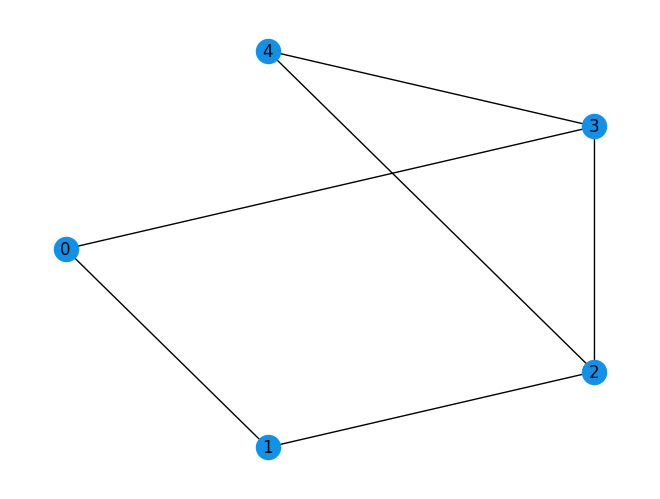

In [2]:
# documentation of rustworkx.PyGraph is here: 
# https://www.rustworkx.org/dev/apiref/rustworkx.PyGraph.html
import rustworkx as rx
from rustworkx.visualization import mpl_draw

n = 5
G = rx.PyGraph()
G.add_nodes_from(range(n))
# The edge syntax is (start, end, weight)
edges = [(0, 1, None), (1, 2, None), (2, 3, None), (3, 0, None), (2, 4, None), (3, 4, None)]
G.add_edges_from(edges)

mpl_draw(G, pos=rx.shell_layout(G), with_labels=True, node_color="#1192E8")

----
#### 5.4 Additional creativity points (up to 15)
My suspicion is that you will find the results from the last two exercises somewhat disappointing.  Take one of the problems and try to improve the result in some way. (This might include using a different quantum algorithm to arrive a solution.)  Provide the following:

* Before showing your improved implementation, describe your approach and why you think it might be successful.
* Show a complete implementation and interpret the results.
* Analyze the effectiveness of your approach and try to explain what worked well and what didn't.